## What Is LangChain

LangChain is a framework for building LLM-powered applications by **composing components together** — prompts, models, output parsers, retrievers, tools — into a single connected pipeline. Where LlamaIndex is purpose-built specifically for the data-retrieval side of things (loading, chunking, indexing, querying), LangChain is broader: it's meant for building the *entire* LLM application logic, of which RAG is just one common pattern among several (chains, tool-calling agents, multi-step workflows).

**The core idea — chaining with `|`(pipe operator), similar to UNIX pipes**

```python
chain = prompt | llm | parser
```

Each piece takes input, transforms it, and passes the result to the next piece — same mental model as `cat file | grep pattern | sort` in the terminal. This composition style is called **LCEL** (LangChain Expression Language), and it's the current, correct API. LangChain had an older "chain" API (`LLMChain`, `SequentialChain`) that's now deprecated — worth knowing this exists.

**The Runnable interface**

Every component in a LangChain pipeline implements a common interface called `Runnable`, giving it three consistent methods: `.invoke()` (run once, get a result), `.stream()` (get output token-by-token as it's generated), and `.batch()` (run multiple inputs at once). This consistency is what makes the `|` chaining work — any two Runnables can be connected together predictably, regardless of what they individually do.

## The Five Core Components

1. **Chat Models** — wrappers around LLM APIs (OpenAI, Anthropic, Gemini). Same role as `Settings.llm` in LlamaIndex, but here you pass the model object directly into the chain rather than setting it globally.
2. **Prompt Templates** — reusable prompt structures with variable placeholders, e.g. `ChatPromptTemplate.from_messages([...])`. LlamaIndex handles prompting mostly implicitly inside `QueryEngine`; LangChain makes you construct this explicitly.
3. **Output Parsers** — convert the LLM's raw text response into a specific structured format (plain string, dict, or a validated Pydantic object).
4. **Retrievers** — fetch relevant chunks from a vector store, same concept as LlamaIndex's retrieval step inside `as_query_engine()`/`as_retriever()`.
5. **Tools** — Python functions the LLM can choose to call. This is new territory - tool-calling/agents.

**Quick Comparison — LangChain vs LlamaIndex**

| Aspect | LlamaIndex | LangChain |
|---|---|---|
| Core focus | Data retrieval pipeline | General LLM app orchestration (chains, tools, agents) |
| RAG setup | `VectorStoreIndex.from_documents()` — mostly implicit | Manually wire retriever + prompt + LLM + parser — more explicit, more control |
| Config style | Global `Settings` object | Pass components directly into the chain |
| Prompting | Hidden by default inside `QueryEngine` | Explicit `ChatPromptTemplate`, always visible |

## Step-by-Step: Three Builds

This section is where theory turns into actual working code — three separate builds, each one layering on a new LangChain capability rather than replacing the previous one. "Build" here just means a small, complete, runnable program — not a large project, just enough code to see one specific pattern work end-to-end.

The three builds, in increasing complexity:
1. **A Simple Chain** — the most basic LCEL pattern: prompt → model → parser, no external data involved
2. **A RAG Pipeline** — adds a retriever into the chain, so the LLM answers using your own documents (same core idea as the entire LlamaIndex pipeline, but built manually here with explicit components instead of a framework doing it implicitly)
3. **A Tool-Calling Agent** — adds the ability for the LLM to call external functions/tools when needed

Each build is meant to be run and understood on its own before moving to the next, since Build 2 and 3 both reuse the chaining concept introduced in Build 1.

### Build 1: A Simple Chain

```bash
pip install langchain langchain-google-genai
```

In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

import nest_asyncio
from dotenv import load_dotenv

nest_asyncio.apply()   # patches Jupyter's event loop for async-based SDK calls
load_dotenv()   # loads GOOGLE_API_KEY from .env

# 1. Create the model
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

# 2. Create a prompt template
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant that explains tech concepts simply."),
    ("user", "Explain {topic} in 3 sentences for a beginner.")
])

# 3. Create an output parser
parser = StrOutputParser()

# 4. Chain them together with LCEL
chain = prompt | llm | parser

# 5. Run it
result = chain.invoke({"topic": "vector databases"})
print(result)

Imagine a regular database as a giant spreadsheet storing exact words and numbers, while a vector database stores information as "concepts" plotted on a 3D map. This allows computers to find things based on meaning and context rather than exact keyword matches. Because of this, they are the secret sauce behind modern AI chatbots, helping them find relevant information in seconds to give you smart answers.


**Walking through each piece**

`ChatPromptTemplate.from_messages([...])` builds a structured prompt from `(role, message)` pairs — `"system"` sets the assistant's behavior, `"user"` is the actual question, with `{topic}` as a placeholder filled in later. This is a structured, reusable version of manually formatting a prompt string each time.

`StrOutputParser()` extracts just the plain text string from the LLM's raw response object (which otherwise includes extra metadata) — without it, `chain.invoke()` would return a full message object instead of clean text.

`chain = prompt | llm | parser` builds the pipeline: your input dict flows into `prompt` (fills the template) → result flows into `llm` (generates a response) → result flows into `parser` (extracts plain text). `.invoke({"topic": "vector databases"})` runs the whole chain in one call.

### Build 2: A RAG Pipeline

This build reconstructs the entire RAG pattern manually — this is a genuinely useful comparison point, *same* end goal in LlamaIndex with `VectorStoreIndex.from_documents()` + `as_query_engine()`, but LlamaIndex does most of this invisibly for you. Here, every piece is explicit: you create the vector store, add documents, build a retriever, format retrieved docs into context, inject that context into a prompt, and chain it all together — nothing is hidden inside a single convenience method.

**Install**

```bash
pip install langchain-google-genai chromadb langchain-chroma langchain-huggingface
```

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

import nest_asyncio
from dotenv import load_dotenv

nest_asyncio.apply()   # patches Jupyter's event loop for async-based SDK calls
load_dotenv()   # loads GOOGLE_API_KEY from .env

# 1. Create embeddings and vector store
embeddings = HuggingFaceEmbeddings(model_name="Qwen/Qwen3-Embedding-0.6B")
vectorstore = Chroma(embedding_function=embeddings)

# 2. Add your documents
docs = [
    "Our API rate limit is 100 requests per minute per key.",
    "Enterprise plans support up to 10,000 requests per minute.",
    "Rate limit errors return HTTP 429 with a Retry-After header.",
]
vectorstore.add_texts(docs)

# 3. Create a retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

# 4. Build the RAG chain
prompt = ChatPromptTemplate.from_messages([
    ("system", "Answer based only on this context:\n{context}"),
    ("user", "{question}")
])

def format_docs(docs):
    return "\n".join(doc.page_content for doc in docs)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
    | StrOutputParser()
)

# 5. Ask a question
answer = rag_chain.invoke("What happens when I hit the rate limit?")
print(answer)

: 

**Note:** `HuggingFaceEmbeddings` here doesn't take `device="cuda"` directly like LlamaIndex's version — GPU control works differently in this package (via `model_kwargs={"device": "cuda"}`), worth flagging now in case it silently runs on CPU when you test this.

**Walking through the new pieces**

`Chroma(embedding_function=embeddings)` creates an in-memory vector store, directly comparable to LlamaIndex's default in-memory `VectorStoreIndex` — same underlying idea, different library. `vectorstore.add_texts(docs)` embeds and stores each string — this is the manual equivalent of what `VectorStoreIndex.from_documents()` does in one call in LlamaIndex.

`retriever = vectorstore.as_retriever(search_kwargs={"k": 2})` — directly comparable to LlamaIndex's `similarity_top_k` parameter; `k=2` here means "retrieve the 2 most relevant chunks," same concept, different parameter name.

`format_docs()` is a plain Python function that joins the retrieved documents' text into one combined string — LangChain doesn't do this formatting for you automatically, unlike LlamaIndex's `QueryEngine`, which handles context-injection into the prompt internally without you writing this step yourself.

**What `format_docs()` Actually Receives**

By the time `format_docs()` gets called, **retrieval has already happened** — `retriever` already filtered your entire document collection down to just the top-k relevant ones (`k=2` here means only 2 documents). `format_docs()` never sees your whole document collection — it only ever receives the small handful of *already-retrieved* documents the retriever selected.

**What the Function Does With Them**

Each retrieved document isn't a plain string — it's a LangChain `Document` object, which has a `.page_content` attribute (the actual text) plus metadata. If you passed a list of these `Document` objects directly into the prompt, the LLM would see something like Python object reprs, not clean readable text.

`format_docs()` exists purely to solve that: it takes the small list of retrieved `Document` objects and joins their `.page_content` text into a single plain string, separated by newlines — so it's genuinely readable when injected into the prompt's `{context}` placeholder.

`{"context": retriever | format_docs, "question": RunnablePassthrough()}` — this is the trickiest new syntax. It's a dictionary where each value is itself a small Runnable chain. `retriever | format_docs` retrieves docs then formats them into one string, feeding the `{context}` slot in the prompt. `RunnablePassthrough()` means "just pass the original input through unchanged" — feeding the `{question}` slot with your original question, untouched.

**LlamaIndex vs LangChain — Same Goal, Very Different Visibility**

| Step | LlamaIndex | LangChain |
|---|---|---|
| Chunking + embedding + storage | 1 line (`VectorStoreIndex.from_documents()`) | Manual: create vectorstore, `add_texts()` |
| Retrieval | `as_query_engine(similarity_top_k=3)` | `as_retriever(search_kwargs={"k": 2})` |
| Injecting context into prompt | Hidden inside `QueryEngine` | You write `format_docs()` and the prompt template yourself |
| Full pipeline | 2-3 lines | ~15 lines, but every step is visible/customizable |

### Build 3: A Tool-Calling Agent

**What "tool calling" actually is**

An LLM cannot execute code, hit an API, or query a database. What it *can* do is look at a JSON schema describing a function (name, description, parameter types) and decide, based on the user's message, that calling that function would help answer the question — then output a structured request to call it, with the arguments filled in.

That's the entire mechanism. The model never runs anything. It just returns something like:

```
{"name": "get_weather", "args": {"city": "Tokyo"}}
```

Your code is responsible for reading that output, actually calling the Python function, and (in a full agent loop) feeding the result back to the model so it can generate a final answer. This is sometimes called "function calling" (OpenAI's original term) or "tool calling" (LangChain/Anthropic's term) — same idea.

This matters because it demystifies "agents." An agent is not the model doing things autonomously — it's a loop your code controls, where the model proposes actions and your code executes them.

**The `@tool` decorator**

`@tool` turns a regular Python function into a LangChain `Tool` object. It uses the function's type hints to build the parameter schema and the docstring as the tool's description — this description is what the LLM reads to decide *when* to use the tool, so it needs to be accurate and specific, not decorative.

**`bind_tools()` and how the model "decides"**

`llm.bind_tools([tool1, tool2])` returns a new runnable that, on every `.invoke()`, sends the tool schemas alongside the prompt to the API. The provider's model (Gemini, GPT, Claude — whichever backend) was fine-tuned specifically to recognize when a tool matches user intent and to emit a structured call instead of plain text. This is a capability of the underlying model, not something LangChain implements — LangChain just standardizes the request/response format across providers.

**Reading the response**

If the model decides to call a tool, `response.tool_calls` is a list of dicts, each with `name` and `args`. If it doesn't need a tool, `tool_calls` is empty and `response.content` has a normal text answer. Your code always has to check `if response.tool_calls:` before deciding how to proceed — this branch is the core control flow of every tool-calling agent.

**Closing the loop (why this is "half" a ReAct agent)**

This tutorial code stops at printing the tool result — it doesn't send that result back to the model. In a real agent, you'd append the tool result as a `ToolMessage` to the conversation and call `.invoke()` again, so the model can turn the raw tool output into a natural-language answer ("The weather in Tokyo is 22°C and sunny"). That send-result-back-and-continue pattern is the **ReAct loop** (Reason → Act → Observe → repeat). LangChain gives you the primitives (`bind_tools`, `tool_calls`, `ToolMessage`) but doesn't run the loop for you — that's what `create_react_agent` (LangGraph) or a manual `while` loop is for. Worth knowing this distinction exists; not worth building a hand-rolled loop from scratch right now — LangGraph will hand you a working one later.

**LangChain vs LlamaIndex tool calling**

You already saw LlamaIndex's version of this via `FunctionTool` / agent runners in reranking-adjacent sections. The underlying mechanism (schema → model decides → structured call → you execute) is identical across both frameworks, because it's the LLM provider's capability, not the framework's. The difference is scope: LlamaIndex's agent abstractions are built specifically around data/retrieval tasks (query engines as tools is a common pattern), while LangChain's `bind_tools` is a general-purpose primitive meant to be composed into arbitrary agent loops via LangGraph.

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

import nest_asyncio
from dotenv import load_dotenv

nest_asyncio.apply()   # patches Jupyter's event loop for async-based SDK calls
load_dotenv()   # loads GOOGLE_API_KEY from .env

# 1. Define tools
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    weather_data = {"London": "12C, cloudy", "Tokyo": "12C, rainy", "Delhi": "40C, sunny"}
    return weather_data.get(city, f"Weather data not available for {city}")

@tool
def calculate(expression: str) -> str:
    """Evaluate a mathematical expression."""
    return str(eval(expression))  # unsafe — fine for learning, not for production

# 2. Bind tools to llm
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
llm_with_tools = llm.bind_tools([get_weather, calculate])

# 3. Call the model — it decides whether to use a tool
response = llm_with_tools.invoke([
    HumanMessage(content="What's the weather in Tokyo?")
])

# 4. Check if it wants to call a tool, and execute it manually
if response.tool_calls:
    for tc in response.tool_calls:
        print(f"Tool: {tc['name']}, Args: {tc['args']}")
        tool_fn = {"get_weather": get_weather, "calculate": calculate}[tc["name"]]
        result = tool_fn.invoke(tc["args"])
        print(f"Result: {result}")

Tool: get_weather, Args: {'city': 'Tokyo'}
Result: 12C, rainy


**Walking through the new pieces**

`HumanMessage(content="...")` — LangChain represents a conversation as a list of message objects (`HumanMessage`, `AIMessage`, `SystemMessage`, `ToolMessage`), rather than plain strings. This matters here because `bind_tools()` changes what the model needs as input: a bare string doesn't carry role information, but tool-calling models need to know "this came from the user" vs "this was my own prior response" vs "this is a tool result," especially once you chain multiple turns together. LlamaIndex has an equivalent (`ChatMessage(role=..., content=...)`) but you likely didn't need it until agent-style workflows — LangChain pushes you into the message-list format earlier because tool calling depends on it structurally.

`response.tool_calls` — this is the field that actually carries the model's decision. `response` here is an `AIMessage` object (not a string), and `AIMessage.tool_calls` is populated only if the model chose to invoke a tool. If it didn't, this list is empty and `response.content` holds a normal text reply instead. This is why the `if response.tool_calls:` check is the branch point of the whole pattern — you're asking "did the model want to act, or just answer?"

Each item in `tool_calls` is a plain dict: `{"name": "get_weather", "args": {"city": "Tokyo"}, "id": "..."}`. `tc["name"]` is the string name of whichever function the model picked — the model chose this by matching the user's question against the docstrings you wrote for `get_weather` and `calculate`, and it can only ever pick from the tools you passed into `bind_tools()`.

`tool_fn = {"get_weather": get_weather, "calculate": calculate}[tc["name"]]` — this is a manual dispatch table: a dict mapping tool name (string) to the actual Python tool object, so you can look up which function to run based on the name the model returned. This step exists because the model only gives you a *name*, not a callable — your code has to bridge that gap. In a larger agent you'd build this dict once from your tools list (e.g. `{t.name: t for t in tools}`) instead of hardcoding it, but hardcoding is fine for two tools in a notebook.

`tool_fn.invoke(tc["args"])` — note this is `.invoke()`, not calling the function directly (`tool_fn(tc["args"])`). That's because `@tool` wrapped your function into a LangChain `Runnable`, same as `prompt`, `llm`, and `parser` were in Build 1 — every LangChain component, including tools, implements the same `.invoke()` interface. `tc["args"]` is already a dict matching your function's parameter names (e.g. `{"city": "Tokyo"}`), so `.invoke()` unpacks it and calls `get_weather(city="Tokyo")` under the hood.

One thing worth being explicit about since it trips people up: at this point in the tutorial's code, the tool result is only printed — it's never sent back to the model. So `response` here is the *first and only* model call; the "answer" the user sees is just the raw tool output (`"22C, sunny"`), not a natural-language sentence from the LLM. Completing that (feeding the result back in as a `ToolMessage` and calling `.invoke()` again) is the piece that turns this into a real ReAct loop.

In [ ]:
# ReAct loop :-

from langchain_core.messages import ToolMessage

# Build the conversation history, including the model's own tool-call response
messages = [
    HumanMessage(content="What's the weather in Tokyo?"),
    response,  # the AIMessage containing the tool_calls from before
]

# Append one ToolMessage per tool call, matching it back via tool_call_id
for tc in response.tool_calls:
    tool_fn = {"get_weather": get_weather, "calculate": calculate}[tc["name"]]
    result = tool_fn.invoke(tc["args"])
    messages.append(ToolMessage(content=result, tool_call_id=tc["id"]))

# Call the model again — now it has the tool result and can phrase a real answer
final_response = llm_with_tools.invoke(messages)
print(final_response.content)   # e.g. "It's currently 22°C and sunny in Tokyo."

[{'type': 'text', 'text': 'The current weather in Tokyo is 12°C and rainy.', 'extras': {'signature': 'El4KXAERTTIPQ4PTsuyGDchM7mSxNKn7YYD+7YCQNe8QjAENd/0vUCsYLkliyI4P8lLw1oFm4cuYZYMPdzuUg3DzyLxKMom8LPS7qloJONGzfcrjLcwWhFZMjEh82tSU'}}]


**What is `tool_call_id`?**

`tool_call_id` is a required field on `ToolMessage` that links a tool's result back to the specific tool call that requested it. When the model returns `response.tool_calls`, each entry already comes with its own `id` — this isn't something you generate yourself, LangChain's normalization layer creates it automatically when it parses the provider's raw response (Gemini, OpenAI, and Anthropic each format tool calls differently under the hood, and LangChain converts all of them into the same dict shape, which includes an `id`). So `tc["id"]` was already populated the moment `response.tool_calls` existed — you were reading a value that LangChain generated for you, not setting one yourself.

The reason this field exists at all: a single model response can contain multiple tool calls in one go (e.g. the model decides to check weather *and* run a calculation in the same turn). If you send back two `ToolMessage` results without saying which result answers which call, the model has no way to match them up correctly. `tool_call_id` is that matching key — it's how the model knows "this specific result answers that specific request."

In [5]:
# Inspect exactly what a tool_call dict contains
print(response.tool_calls)

[{'name': 'get_weather', 'args': {'city': 'Tokyo'}, 'id': 'call_187325', 'type': 'tool_call'}]


## LangChain Architecture and Design

LCEL chains work by passing data through each component in sequence — the input to one component becomes the output of the previous one. The LCEL runtime is the layer that manages streaming, batching, and error propagation across that sequence automatically, so you don't have to write that handling yourself.

### How LCEL Chains Execute

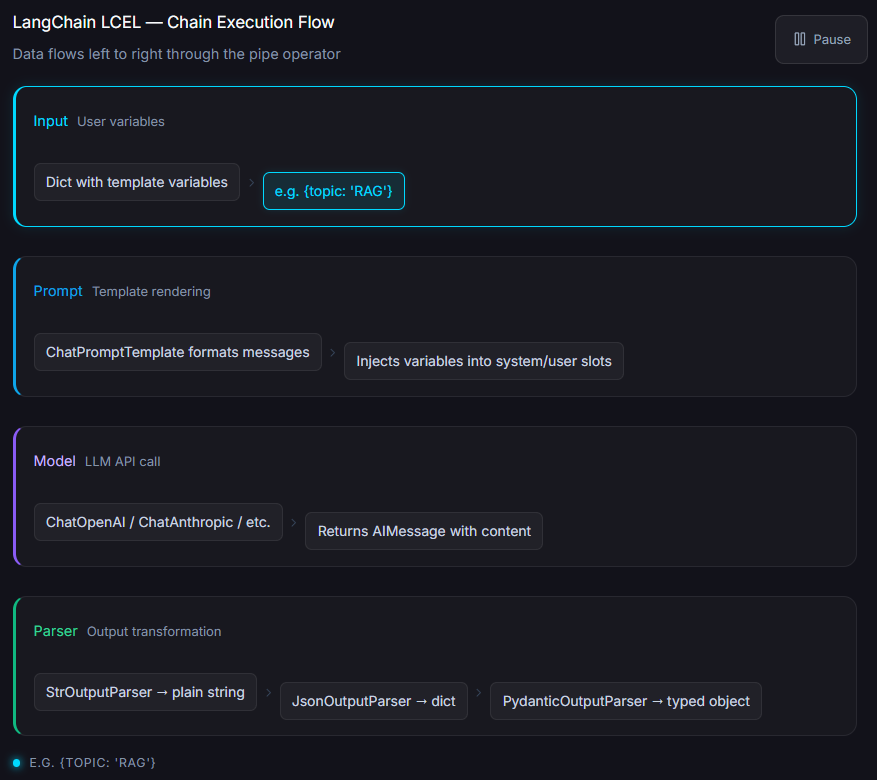

For a chain like `prompt | llm | parser`, data flows through four stages in order:

**1. Input — user variables**

A dict containing the template variables, e.g. `{"topic": "RAG"}`. This is what you pass into `.invoke()`.

**2. Prompt template rendering**

`ChatPromptTemplate` takes that dict and formats it into actual messages — injecting `"RAG"` into whichever system/user slot the template defined (`{topic}`). Output at this stage is a list of formatted messages, not text yet.

**3. Model — LLM API call**

The formatted messages are sent to whichever chat model is in the chain (`ChatOpenAI`, `ChatAnthropic`, `ChatGoogleGenerativeAI`, etc.). The provider package handles the actual API call. This returns an `AIMessage` object, not a plain string.

**4. Parser — output transformation**

The `AIMessage` is transformed into whatever shape you asked for: `StrOutputParser` gives you a plain string, `JsonOutputParser` gives you a dict, `PydanticOutputParser` gives you a validated typed object.

Each of these four stages is a `Runnable`, and the pipe operator (`|`) just wires "output of this stage becomes input of the next stage" — that's the entire mechanism behind LCEL chains.

### The LangChain Component Stack

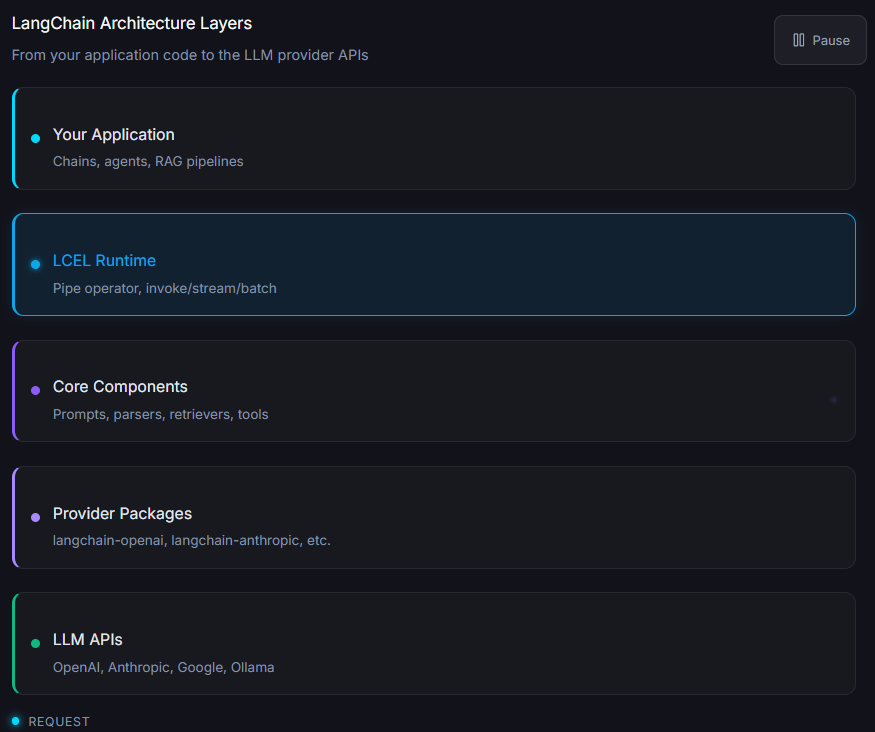

This is the layering of your application down to the actual LLM provider, top to bottom:

**Your Application**

The chains, agents, and RAG pipelines you actually write — Build 1, Build 2, Build 3.

**LCEL Runtime**

The pipe operator and the `.invoke() / .stream() / .batch()` methods — this is what executes your chain and handles streaming, batching, and error propagation automatically underneath it.

**Core Components**

The building blocks you compose into chains: prompts, parsers, retrievers, tools.

**Provider Packages**

`langchain-openai`, `langchain-anthropic`, `langchain-google-genai`, etc. — these translate LangChain's generic `Runnable` calls into each provider's specific API request/response format.

**LLM APIs**

The actual provider endpoints being called: OpenAI, Anthropic, Google, Ollama.

Every component in this stack implements the same `Runnable` interface, which is why any component can be swapped, composed, or parallelized without changing the rest of the chain.

## LangChain Tutorial Code Examples

These three patterns extend the basic `prompt | llm | parser` chain you already built in Build 1 — none of them require new chain structure, just different methods called on the same chain, or a different way of composing Runnables.

### Streaming Responses

`.invoke()` waits for the entire response before returning anything. `.stream()` instead returns tokens as they're generated by the LLM, which is why real chat UIs (ChatGPT, Claude's own interface) show text appearing word-by-word instead of all at once after a pause.

This works because every component in the chain — not just the LLM — supports streaming. The prompt renders instantly since there's nothing to wait on. The LLM streams tokens from the API as they're generated. And critically, the parser processes each token chunk as it arrives rather than waiting for the full message — `StrOutputParser` yields each text chunk immediately instead of buffering everything and returning one string at the end. This chaining of streaming behavior through every stage is exactly what the LCEL runtime was described as managing "automatically" in the architecture section — you don't write any of this yielding logic yourself.

In [8]:
chain = prompt | llm | parser

for chunk in chain.stream({"topic": "neural networks"}):
    print(chunk, end="", flush=True)  # flush=True forces immediate terminal output per chunk, instead of buffering

Neural networks are computer systems inspired by the human brain that learn to recognize patterns from data. They are made of connected layers of artificial "neurons" that pass information to each other, getting better at a task over time through practice. This is the technology behind everything from voice assistants to self-driving cars.

Practically: use `.invoke()` when you need the full response before doing anything with it (e.g. passing it to another function). Use `.stream()` when the response is going straight to a user-facing UI.

### Switching Models

Because every chat model wrapper (`ChatOpenAI`, `ChatAnthropic`, `ChatGoogleGenerativeAI`) implements the same `Runnable` interface, the only thing that changes when swapping providers is which class you instantiate — the rest of the chain (`prompt | ... | parser`) and the way you call it (`.invoke()`, `.stream()`) stays identical. This is the direct payoff of the "Provider Packages" layer from the architecture section: each provider package is responsible for translating the generic call into that provider's actual API format, so your chain code never needs to know the difference.

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from langchain_google_genai import ChatGoogleGenerativeAI

# Same chain, different models
chain_gpt = prompt | ChatOpenAI(model="gpt-4o") | parser
chain_claude = prompt | ChatAnthropic(model="claude-sonnet-4-20250514") | parser
chain_gemini = prompt | ChatGoogleGenerativeAI(model="gemini-2.0-flash") | parser

# Same invoke interface
result = chain_gpt.invoke({"topic": "transformers"})

In a real project this matters for two reasons: cost/latency tradeoffs (swap to a cheaper or faster model without touching pipeline logic), and provider outages — if Gemini has downtime, you can fail over to another provider's chat model as a fallback without rewriting your RAG or agent code.

### Parallel Execution with RunnableParallel

Normally, chaining components with `|` runs them sequentially — one finishes before the next starts. `RunnableParallel` instead runs multiple independent chains concurrently and returns their results together as a dict, keyed by whatever names you give them.

This is useful specifically when you need multiple *different* outputs from the *same* input, and those outputs don't depend on each other — for example, summarizing text, extracting keywords, and running sentiment analysis on the same input text. Running these three sequentially would mean three back-to-back API calls; running them in parallel means the wait time is roughly as long as the slowest single call, not the sum of all three.

In [12]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")
parser = StrOutputParser()

# Each prompt asks the LLM to do a different task on the same {text} input
prompt_summary = ChatPromptTemplate.from_messages([
    ("system", "Summarize the given text in one sentence."),
    ("user", "{text}")
])

prompt_keywords = ChatPromptTemplate.from_messages([
    ("system", "Extract the 3 most important keywords from the given text, comma-separated."),
    ("user", "{text}")
])

prompt_sentiment = ChatPromptTemplate.from_messages([
    ("system", "Classify the sentiment of the given text as Positive, Negative, or Neutral. Reply with one word."),
    ("user", "{text}")
])

from langchain_core.runnables import RunnableParallel

parallel = RunnableParallel(
    summary=prompt_summary | llm | parser,
    keywords=prompt_keywords | llm | parser,
    sentiment=prompt_sentiment | llm | parser
)

# All three run concurrently
results = parallel.invoke({
    "text": "The product launch was a massive success, exceeding sales targets by 340% in the first week. "
            "Customer feedback has been overwhelmingly positive, particularly around the new battery life "
            "and camera improvements. However, some users reported issues with the companion app crashing "
            "on older Android devices, which the support team is now investigating."
})

print(results["summary"])
print(results["keywords"])
print(results["sentiment"])

Despite some minor app-crashing issues on older Android devices, the product launch was a massive success, exceeding sales targets by 340% in its first week due to overwhelmingly positive customer feedback on its battery life and camera improvements.
product launch, customer feedback, companion app
Positive


All three share the same input variable name (`{text}`), which is what allows `parallel.invoke({"text": "..."})` to feed the identical input into all three chains at once — `RunnableParallel` doesn't route different inputs to different chains, it broadcasts the same input dict to every chain in parallel.

**How deep to go here:** streaming and model-switching are things you'll actually use in real projects (streaming for any user-facing app, model-switching for cost/fallback logic) — worth being comfortable with both. `RunnableParallel` is good to recognize and understand conceptually, but you're unlikely to reach for it often in typical RAG/agent work compared to sequential chains — don't over-invest here.

## Trade-offs and Pitfalls

LangChain wraps the messy parts of talking to an LLM (formatting requests, parsing responses, switching providers) into simple, reusable pieces like `prompt | llm | parser` — this wrapping is called an **abstraction** (a layer that hides the low-level details underneath so you work with something simpler on top). This speeds up prototyping, but it comes at a cost: when something breaks, it might be breaking *inside* that hidden layer, not in your own code — so debugging means digging through LangChain's internals, not just your own logic. LangChain also ships new versions frequently, and those updates sometimes change how things work, which can break code that worked fine before. For a simple task, all this machinery can also just be more than you actually need.

### Raw SDK & Pydantic AI

**Raw SDK** means skipping LangChain entirely and calling the LLM provider's own official Python library directly — e.g. `google-generativeai` for Gemini, `openai` for OpenAI. No framework in between. You write the API call, format the prompt, and parse the response yourself, in plain Python. Nothing is hidden — you see and control every step.

**Pydantic AI** is a smaller, lighter framework built by the same team behind the Pydantic library. It focuses on one specific job: making sure the LLM's output comes back as clean, validated, typed data instead of raw text you have to parse yourself. It doesn't have LangChain's pipe syntax or its huge library of pre-built integrations — it's a middle ground, offering more structure than a raw SDK call, but far less machinery than LangChain.

### LangChain vs Raw SDK / Pydantic AI

| | LangChain | Raw SDK / Pydantic AI |
|---|---|---|
| **Philosophy** | Batteries-included framework with 700+ integrations | Minimal wrapping, maximum control |
| **Composability** | Chain steps together with `\|` (`prompt \| llm \| parser`) | You write the connecting logic yourself |
| **Pre-built components** | Ready-made RAG, agent, and retriever components | None — you build everything from scratch |
| **Provider switching** | Swap `ChatOpenAI` for `ChatGoogleGenerativeAI` in one line | Requires rewriting provider-specific code (raw SDK) |
| **Streaming / batching** | Built in automatically | You implement it yourself (raw SDK) |
| **Debugging** | Harder — errors can occur inside LangChain's own code, not just yours | Easier — you wrote every line, so you know exactly what's running |
| **API stability** | Frequent releases, occasional breaking changes | Stable — fewer surprises across versions |
| **Learning curve** | Steep — many abstractions and naming conventions to learn | Shallow — it's just Python and one HTTP client |

**Verdict:** Use LangChain when you want pre-built components (retrievers, agent tooling, provider-agnostic chains) and want to prototype fast. Use a raw SDK or Pydantic AI when you need full control, simpler debugging, and don't need LangChain's ecosystem of integrations.

### Why this matters?

Here we've been building everything through LangChain and LlamaIndex so far — both wrap a lot of the low-level work for you. It's worth knowing that for a simple production feature that's just "send one prompt, get one answer," pulling in LangChain is often unnecessary — a raw SDK call is fewer lines, easier to debug, and won't break when LangChain ships a new version. You'll reach for LangChain/LlamaIndex specifically when you need their composition or retrieval machinery — which is most of what you're building right now — not by default for every single LLM call.

## Where Engineers Get Burned

**Don't learn LangChain's legacy API** — LangChain went through a major rewrite from the old "chains" API (`LLMChain`, `SequentialChain`) to LCEL (the pipe operator, `|`). If a tutorial or Stack Overflow answer uses `LLMChain`, it's from 2023–early 2024 and outdated. Everything you've built so far (Build 1–3) uses LCEL — that's the current standard. Good to know this exists purely so you're not confused if you stumble on old code while searching for help later.

**Over-abstracting simple tasks** — if you just need one prompt → one response, use the raw SDK directly instead of LangChain. LangChain earns its complexity when you need composition (chaining steps), retrieval (RAG), or tool calling — not for a single API call. You already noted this yourself in the trade-offs section.

**Ignoring token costs in RAG** — retrieving 10 chunks and stuffing all of them into the prompt can cost 5–10x more per query than retrieving 2–3 focused chunks, since you're paying for every token sent to the LLM as context. Always set `search_kwargs={"k": 3}` (or similar, tuned per use case) rather than defaulting to a large `k`. You already used `k=2` in Build 2 — this is just the reasoning behind why that number matters, not just "top N results."

**Not pinning versions** — LangChain ships frequent releases (occasionally weekly) and sometimes breaks backward compatibility. Pin exact versions in `requirements.txt` (e.g. `langchain==0.3.x`, `langchain-core==0.3.x`) so your project doesn't silently break when you reinstall dependencies later.

**Forgetting async in web apps** — if you ever deploy a chain inside a web framework (FastAPI, Django), use `await chain.ainvoke()` instead of `chain.invoke()`. The sync version blocks the event loop, meaning your entire server can't handle other requests while waiting on one LLM call. Not relevant to notebook work now, but worth remembering once you build an API around any of this.

---

## Interview Questions Worth Knowing

**"What is LCEL and why does LangChain use it?"**
Answer using what you already know: LCEL is the pipe-based syntax where every component implements the `Runnable` interface (`.invoke()`, `.stream()`, `.batch()`). It replaced the old `LLMChain`/`SequentialChain` API because it's more composable and supports streaming natively — you've now built this yourself three times, so this should be an easy one.

**"Walk me through how you'd build a RAG pipeline with LangChain."**
You can answer this directly from Build 2: chunk and embed documents into a vector store (Chroma), create a retriever with `.as_retriever()`, combine retrieved context with the question in a prompt template, pass to the LLM, parse the response. Mention the real decision points: chunk size, embedding model choice, `k` (number of retrieved chunks), and whether to add reranking — this last point ties directly to what's coming in your advanced RAG phase.

**"When would you not use LangChain?"**
This is the trade-offs section, framed as an interview answer: skip it for simple single-model calls (raw SDK is cleaner), skip it when you need fine-grained control over retry logic or streaming protocols, and Pydantic AI is worth mentioning as the type-safety-focused alternative for structured output tasks.

**"What's the difference between LangChain and LangGraph?"**
LangChain = linear pipelines, data flows one direction. LangGraph = stateful workflows with cycles — the agent can loop back, retry, and persist state. Most production systems use LangChain components *inside* LangGraph nodes rather than picking one exclusively.

---

## Production Deployment Tips

**Version pinning** — same point as above, restated for production specifically: pin `langchain` and `langchain-core` exactly. Weekly releases plus occasional breaking changes means unpinned dependencies are a real production failure mode, not a theoretical one.

**Observability via LangSmith** — setting `LANGCHAIN_TRACING_V2=true` turns every chain execution into a traceable span you can inspect. Worth knowing this exists as the standard tool for debugging *why* a RAG pipeline returned a wrong answer — without tracing, you're debugging blind through multiple chain steps. Not something to set up right now, but good to know the name for when you eventually deploy something real.

**RAG optimization in production** — the retriever you built in Build 2 (`vectorstore.as_retriever()`) is a starting point, not the production pattern. Real systems layer in reranking (Cohere Rerank or cross-encoder models.

**Cost monitoring** — log token usage per request via LangChain's callbacks system. A misconfigured RAG chain (too many retrieved chunks, an oversized system prompt) can cost 10–50x more than a tuned one. Same underlying point as the "ignoring token costs" pitfall above — cost control isn't a one-time setting, it's something you monitor continuously in production.

**LangGraph migration path** — teams that start with plain LangChain chains often migrate to LangGraph specifically when they need cycles, persistence, or human-in-the-loop steps. The migration is smooth because LangChain components (your prompts, parsers, tools) work unchanged inside LangGraph nodes — you're not throwing away what you're building now, you're wrapping it in a different execution model later.

This confusion makes total sense — you're not wrong that both *can* do RAG. The real difference is what each framework is fundamentally built around, and where its depth actually lies.

## LlamaIndex vs LangChain

| | LlamaIndex | LangChain |
|---|---|---|
| **Core identity** | Data framework — retrieval is the system, not a feature | Orchestration framework — retrieval is one Runnable among many |
| **Mental model** | Ingest documents → build index → query → synthesize answer | Compose arbitrary steps with `\|` — prompt, LLM, retriever, tool, anything |
| **RAG depth** | Structurally ahead — multiple index types (vector, list, tree, keyword, graph), built-in query planning, sub-question decomposition | Gives you more explicit manual control over each RAG step (you write `format_docs` yourself, as you did in Build 2) |
| **Agents / tool calling** | Exist but feel secondary — grafted onto a retrieval-first design | First-class — this is what the framework is structurally built around, especially via LangGraph |
| **Best for** | Retrieval-grounded answers with optional tool calls — when retrieval quality on your documents is the actual product | Agents that occasionally retrieve — complex multi-step workflows, tool-heavy orchestration |
| **Document ingestion** | More thought-through abstractions for loading, chunking, and indexing varied document types (PDFs, Word, Notion, web, DB rows) | Less specialized here — you handle more of this manually |
| **Code verbosity for RAG** | Fewer lines — chunking, embedding, retrieval are built into the index abstraction itself | More lines, but more explicit control at each step |
| **Production pattern (2026)** | Commonly used as the retrieval layer *inside* a LangChain/LangGraph agent | A common 2026 pattern pairs LlamaIndex for indexing/ingestion with LangGraph for orchestration — they're designed to integrate |

## Practical takeaway for you

You're not choosing one over the other for your career — most production teams use each where it is strongest, and most production AI-first teams use both, with LlamaIndex as the retrieval layer inside a LangChain or LangGraph agent. Learning both is exactly the right move — you'll likely end up combining them in your large RAG project: LlamaIndex-style indexing depth for retrieval quality, LangChain/LangGraph for the agent/tool-calling layer around it.